In [26]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    sys.path.insert(0, str(Path.cwd() / "src"))  # ensure A_Config is importable before project_root is known
    from A_Config import REPO_ROOT
    project_root = Path(REPO_ROOT)  # computed from A_Config.py's own location, so it's correct on any machine/mount
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")
case_name = "07_Tropea_cafe"
experiment = "Cat_walk"
Question = "Where is the first cat in this video?"

asset_name = f"{case_name}_{experiment}"

sys.path.insert(0, str(project_root / "src")) # added for bufflehead
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_cam_poses" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment
ply_dir             =   VGGT_O_output_dir  /"ply"         
#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/workspaces/MScPROJECT_LOCAL True
Case    : 07_Tropea_cafe
Video   : VID_20260530_113822990.mp4


PRODUCER IS ACTIVE FROM HERE

project_root: /cs/student/project_msc/2025/cgvi/dbarker
{1661: array([ 0.00042413, -0.00027182, -0.00024412], dtype=float32), 1687: array([-0.01729021, -0.00078868, -0.01795009], dtype=float32), 1700: array([-0.0336572 , -0.00115414, -0.01596571], dtype=float32), 1725: array([-0.02998923, -0.00090062, -0.02461929], dtype=float32), 1750: array([-0.02056506, -0.00296033, -0.00772115], dtype=float32), 1775: array([-0.01059491, -0.00149169,  0.01110664], dtype=float32), 1800: array([-0.01159434, -0.00139806,  0.02074549], dtype=float32), 1825: array([-0.01394914, -0.00216532,  0.02255267], dtype=float32), 1850: array([-0.01209545, -0.00122079,  0.0293278 ], dtype=float32), 1875: array([-0.01682271, -0.00174239,  0.03521781], dtype=float32), 1900: array([-0.02000528, -0.00207842,  0.05040385], dtype=float32), 1923: array([-0.02530777, -0.00217516,  0.04945162], dtype=float32), 1947: array([-0.05855169, -0.00303066,  0.01566616], dtype=float32), 1966: array([-0.05332902, -0.00014073, -0.0024

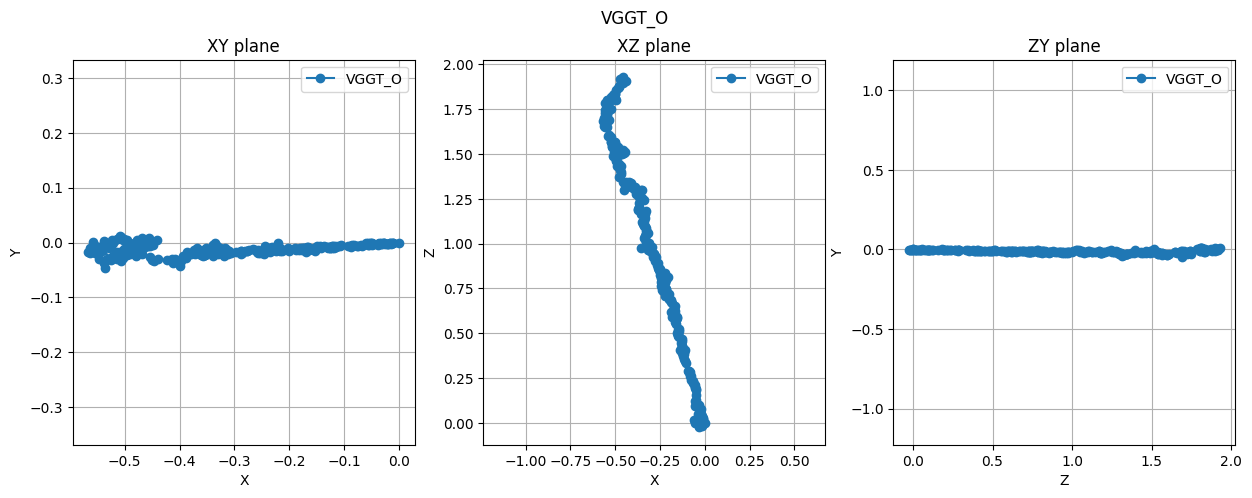

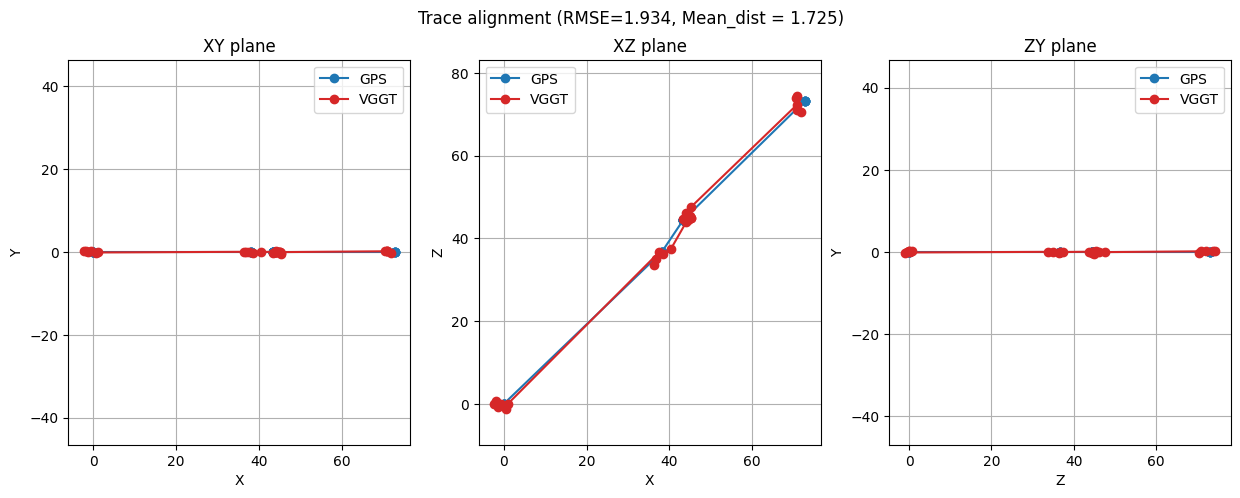

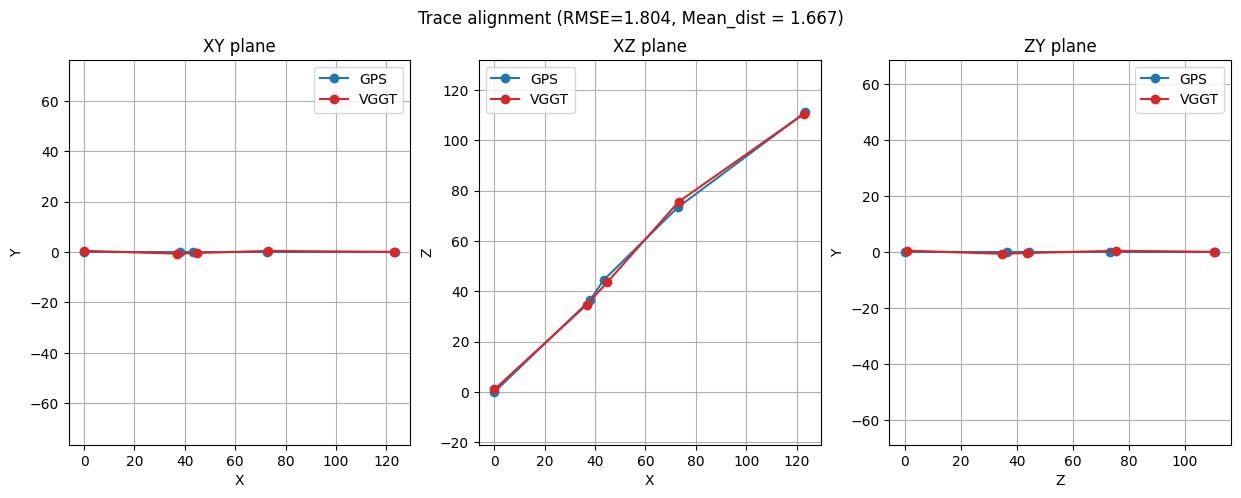

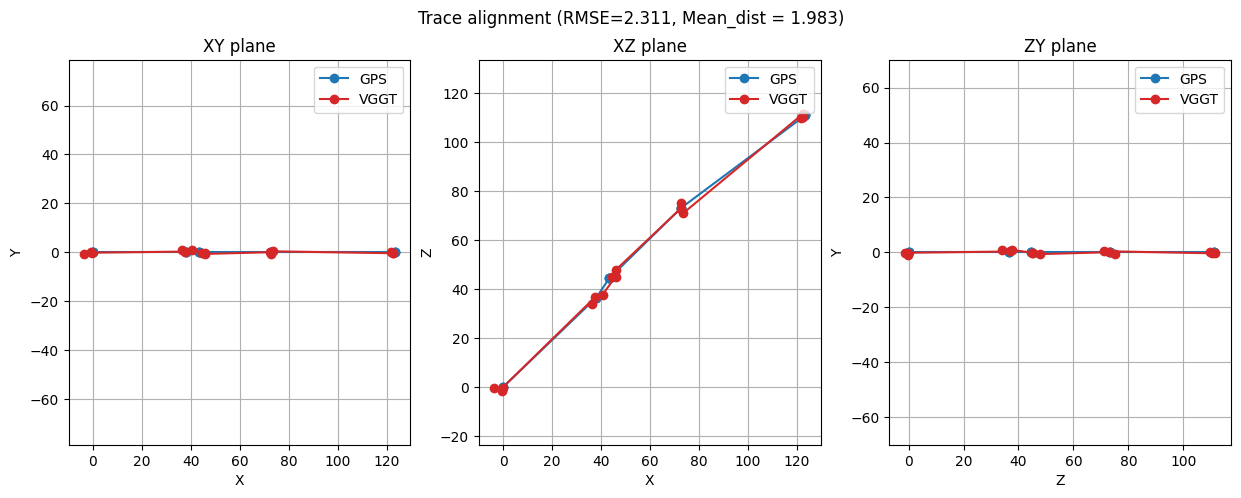

In [31]:
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
#get lat lon positions
#get transforms to convert other things too
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
from A_Config import case_dir

from F_post_recon_processing import Reconstruction

#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
#get lat lon positions
#get transforms to convert other things too
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
from A_Config import case_dir

from F_post_recon_processing import Reconstruction
from F_post_recon_processing import load_reality_scan_trace, load_VGGT_O_trace

VGGTO,VGGTO_dict  = load_VGGT_O_trace((predictions_path), frames_dir = frames_for_recon)
print(VGGTO_dict)



csv_path_pose = reg_dir   /"camera_poses.csv"
csv_path_GPS  =case_dir()/"000_GPS_Data"/"GPS_tags_v01.csv"
cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, VGGTO_dict, Source = "VGGT")
csv_path_GPS  =case_dir()/"000_GPS_Data"/"GPS_tags_v02.csv"
am_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, VGGTO_dict, Source = "VGGT")
csv_path_GPS  =case_dir()/"000_GPS_Data"/"GPS_tags_v03.csv"
cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, VGGTO_dict, Source = "VGGT")





In [32]:
#LOAD VGGT_O recon for further processing
if flags["MULTI_PART_RECON"] == False:
    from F_post_recon_processing import Reconstruction
    recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)
else:
    print("Cell Disabled")

Subject VGGT-O → real-world: 21 pairs, RMSE = 0.0512 m
[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
/workspaces/knuckles_drive/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_agent_temp/predictions.npz


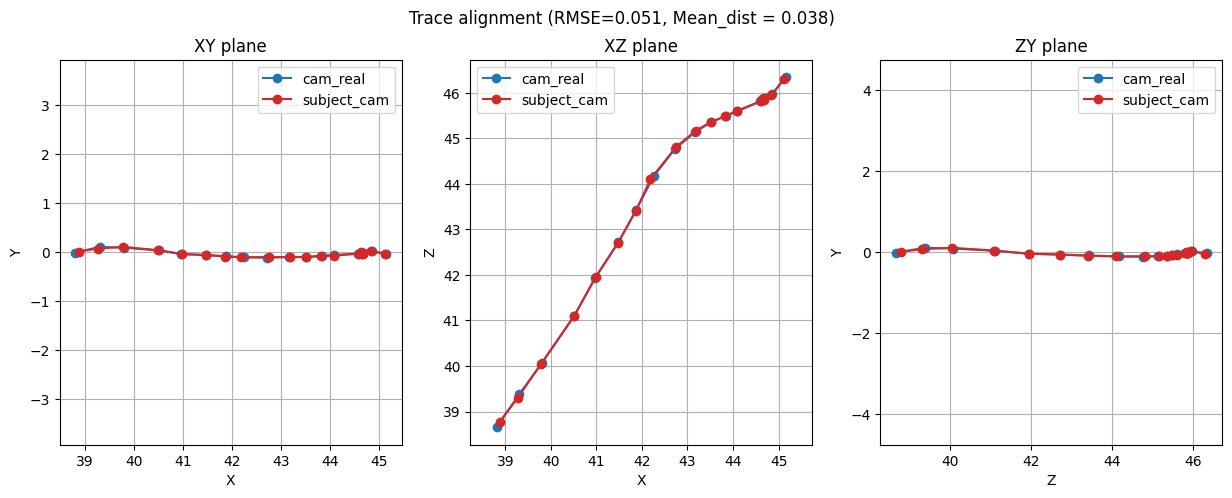

In [35]:
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
MULTI_PART_RECON = False
if flags["RECON_CAM_POSES"] == True and flags["VGGT_O_RECON"] ==True:
    if MULTI_PART_RECON == False:
        from Q_subject_analysis import subject_to_metric_and_gps_space
        from G_transforms_alignments import  recon_to_recon_transform
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

        sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
            recon,
            masks_dir        = str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
            )    

        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
        _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
        print(predictions_path)
    else:
        print("Cell disabled")
else:
     print("Cell disabled")

In [ ]:
# Cell — PLY visualisation
if flags["CUT3R_RECON"] == True and flags["RECON_3D"] == True:
        
    import importlib, sys
    sys.path.insert(0, str(project_root / "src"))

    import D_cut3r_vis; importlib.reload(D_cut3r_vis)
    from D_cut3r_vis import visualise_cut3r
    visualisation_dir = case_dir   /  VGGT_O_output_dir
    #visualisation_dir = case_dir   /  CUT3R_output_dir
    visualise_cut3r(visualisation_dir)


Found 92 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

subject moved 6.679762539165677 m
subject moved in a 205.05716821938583 direction


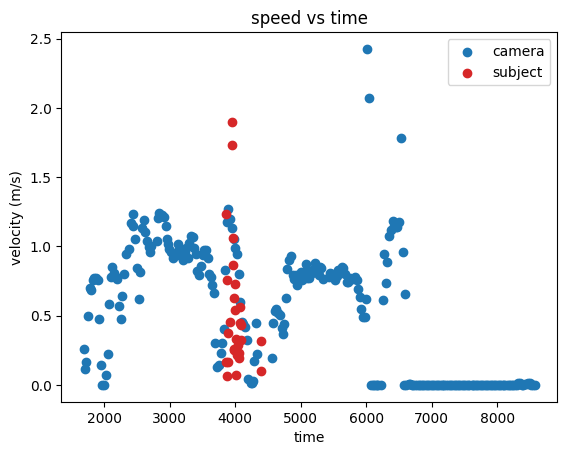

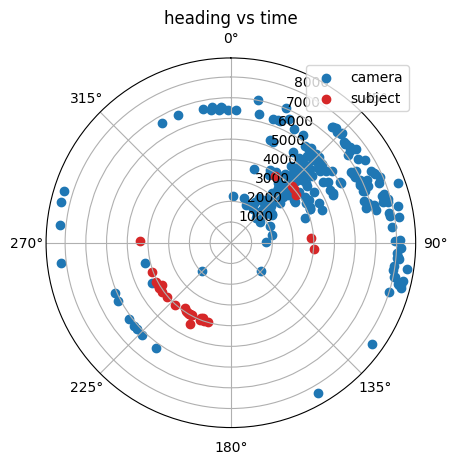

In [36]:
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(sub_pos_real_dict,cam_poses_realworld_dict,lat_0, lon_0 )



Text(0.5, 1.0, 'Subject position by shard (color = time)')

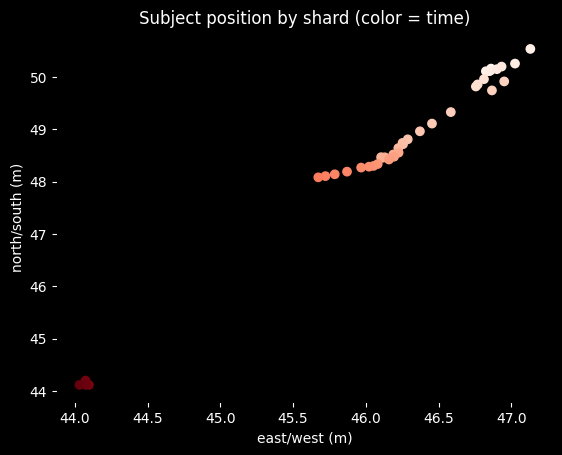

In [10]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
pts = np.array([sub_pos_real_dict[k] for k in sorted(sub_pos_real_dict)])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")


In [37]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Auto-zoom: 19, centre (38.67586, 15.89581)
Fetching map...
  Fetching: https://maps.googleapis.com/maps/api/staticmap?center=38.67586296091851,15.89580...
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/07_Tropea_cafe_cat_03_agent_temp_map.svg  (124 KB map, 183 KB SVG)
Rendering frames...
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/map_frames  (180 frame PNGs)
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/07_Tropea_cafe_cat_03_agent_temp_map.gif  (14316 KB GIF)


In [ ]:
#CAMERA TRANSFORMS - single recon at the moment
#1m up
ext = recon.preds["extrinsic"][9].clone()
ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
ext9 = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [ ]:
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from B_video_processing import available_frames
    
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)
    
    
    if MULTI_PART_RECON == True:
      recon = recons
      point_cloud_xforms = point_cloud_xforms
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        main_idx      = 3908,
        extra_indices = range (3854,4397),
          #other syntax  [400,4027, 4052, 4065],
          #extra_indices = [extra_indices], - for composite (double [[]])
        masks_dir     = str(yolo_masks_dir),
        point_cloud_xforms = point_cloud_xforms

        new_view = ext ,
        
        confidence_threshold = 2
       
       )
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#render projection of 3D points clouds
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:

#cutr point cloud render
if flags["CUT3R_RECON"] ==True:  
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_CUT3R


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#4D viewer
if flags["VGGT_O_RECON"] ==True:
     ply_dir = VGGT_O_output_dir  /"ply"  
from U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

scenepic[info]> Disabling VideoWriter due to ImportError


In [23]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/report_07_Tropea_cafe_cat_03.csv'

In [8]:
if flags["MAKE_MOVIE"] ==True:
  #MAKING A MOVIE
  '''This controls M_scoring. It's independent of scene recon, so could be placed anywhere'''
  '''bring in M_scoring_controls'''
  from W_video_editor import video_overlay_edit
  movie_start = movie_start
  moveie_end = movie_end
  movie =video_overlay_edit(video_path, 
                            movie_start, 
                            moveie_end, 
                            yolo_masks_dir, 
                            3777, 4557,
                            handles=2, 
                          color=(0, 200, 0), 
                          alpha=0.4) 

NameError: name 'movie_start' is not defined

In [11]:
if flags["MAKE_MOVIE_CUTS"] == True:
    import W_video_editor
    W_video_editor.find_all_cut_points(video_path)
    W_video_editor.assemble_paper_edit(video_path)
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
from A_Config import assets_dir
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()

On May 30, 2026, at 11:40:31, a cat was captured on video wandering along a street in Tropea.

The cat, highlighted with a green tracking mask, is seen walking on the road near a parked black Volkswagen. It moves slowly along the street pavement, staying close to the curb and the front of the parked car.

A woman wearing a straw hat and a red sleeveless top walks past and observes the cat, while voices can be heard reacting to the feline's presence. This interaction and the cat's movement are documented from 11:40:31 to 11:40:49, spanning a duration of approximately 18.33 seconds.
**00:07** [Woman]: Guarda! Miao.

**00:10** [Woman]: No.

**00:12** [Woman]: No. No.

**00:17** [Woman]: Ma tu...

**00:21** [Woman]: No.


In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


  'Title' -> shape 'Title'
  'place' -> shape 'place'
  'overlay_mp4' -> shape 'overlay_mp4'
  'map_gif' -> shape 'map_gif'
  'speed_graph' -> shape 'speed_graph'
  'projection_mp4' -> shape 'projection_mp4'
  'point_cloud_render_VGGT_O_gif' -> shape 'point_cloud_render_VGGT_O_gif'
  'point_cloud_render_CUT3R_gif' -> shape 'point_cloud_render_CUT3R_gif'
  'transcript' -> shape 'transcript'
  'event_description' -> shape 'event_description'
  '4D_recon_clicker' -> shape '4D_recon_clicker'
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)

Saved: /workspaces/knuckles_drive/Data/07_CAT_TEST/100_Powerpoint/07_CAT_TEST_v_01.pptx
